# 📊 Audit SND30 — Intelligence Artificielle et Finances Publiques
**ISE3-DS · ISSEA · Yaoundé — Année académique 2025-2026**

> *Comment l'IA peut-elle mesurer mathématiquement l'évolution des priorités de l'État camerounais entre la Loi de Finances 2024 et les perspectives 2025-2026 ?*

---
## Pipeline

| Étape | Module | Description |
|-------|--------|-------------|
| 0 | Configuration | Piliers SND30, chemins, hyperparamètres |
| 1 | Extraction PDF | pdfplumber → lignes budgétaires |
| 2 | Classification NLP | Zero-shot XLM-R → Fine-tuning CamemBERT |
| 3 | Glissement sémantique | Jensen-Shannon + TF-IDF Cosinus + Δ AE/CP |
| 4 | Alignement statistique | Test du Chi² vs cibles SND30 |
| 5 | Visualisations | Tableaux de bord Plotly interactifs |


---
## 0. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
import json, re, os

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 110

import sys
sys.path.insert(0, str(Path.cwd().parent))

from audit_snd30.config import (
    PILIERS, CIBLES_SND30, COULEURS_PILIERS,
    COULEUR_2024, COULEUR_2025,
    PROC_DIR, MODEL_DIR,
    PDF_2024, PDF_2025,
    ZEROSHOT_MODEL, FINETUNE_MODEL, EMBEDDING_MODEL,
    TRAIN_EPOCHS, BATCH_SIZE, LEARNING_RATE, WEIGHT_DECAY,
    WARMUP_RATIO, EARLY_STOP_PAT, SEUIL_ZEROSHOT, SEUIL_PRED, MIN_CONFIANCE_FT
)

print('Piliers SND30 :', PILIERS)
print('Cibles SND30  :', CIBLES_SND30)
print('PROC_DIR      :', PROC_DIR)
print('Imports OK')


Piliers SND30 : ['Transformation Structurelle', 'Capital Humain', 'Gouvernance', 'Développement Régional']
Cibles SND30  : {'Transformation Structurelle': 0.35, 'Capital Humain': 0.3, 'Gouvernance': 0.2, 'Développement Régional': 0.15}
PROC_DIR      : C:\Users\Ultra Tech\Downloads\projet_chouta_ambassa\audit_snd30\Projet_NLP_DSM_2026_ISSEA\data\processed
Imports OK


---
## 1. Extraction des Lignes Budgétaires (PDF MINFI)

Les extracteurs `lf_2024.py` / `lf_2025.py` utilisent **pdfplumber** avec des heuristiques de positionnement (coordonnées x/y) pour isoler CODE · LIBELLE · AE · CP.

| Paramètre | LF 2024 | Rôle |
|-----------|---------|------|
| `x_ae_min/max` | 430–493 | Colonne AE |
| `x_cp_min/max` | 493–555 | Colonne CP |
| `x_lib_min/max` | 120–246 | Libellé |
| `max_amount` | 999 000 000 | Filtre erreurs OCR |


In [2]:
from audit_snd30.extraction.lf_2024 import extraire_lf2024
from audit_snd30.extraction.lf_2025 import extraire_lf2025

# Option A : extraction depuis PDF (décommenter si les PDFs sont disponibles)
# df_raw_2024 = extraire_lf2024(str(PDF_2024), out_dir=PROC_DIR)
# df_raw_2025 = extraire_lf2025(str(PDF_2025), out_dir=PROC_DIR)

# Option B : chargement des fichiers extraits
def charger_brut(nom, annee):
    path = PROC_DIR / f'{nom}.xlsx'
    if path.exists():
        df = pd.read_excel(path)
        print(f'[LF {annee}] {len(df)} lignes chargees depuis {path.name}')
        return df
    print(f'[LF {annee}] Introuvable : {path}')
    return None

df_raw_2024 = charger_brut('lignes_budgetaires_2024', 2024)
df_raw_2025 = charger_brut('lignes_budgetaires_2024_2025', 2025)


[LF 2024] 145 lignes chargees depuis lignes_budgetaires_2024.xlsx
[LF 2025] 176 lignes chargees depuis lignes_budgetaires_2024_2025.xlsx


In [4]:
def explorer_df(df, annee):
    if df is None:
        print(f'[LF {annee}] non disponible')
        return
    print(f'LF {annee} : {df.shape} | colonnes : {list(df.columns)}')
    print(f'  Total AE : {df["AE"].sum():,.0f} k FCFA')
    print(f'  Total CP : {df["CP"].sum():,.0f} k FCFA')
    print(f'  Nulles   : {df.isnull().sum().to_dict()}')
    print()

explorer_df(df_raw_2024, 2024)
explorer_df(df_raw_2025, 2025)

if df_raw_2024 is not None:
    display(df_raw_2024.head(8))


LF 2024 : (145, 6) | colonnes : ['Ligne', 'N°', 'CODE', 'LIBELLE', 'AE', 'CP']
  Total AE : 6,286,742,197 k FCFA
  Total CP : 6,057,126,301 k FCFA
  Nulles   : {'Ligne': 0, 'N°': 3, 'CODE': 0, 'LIBELLE': 0, 'AE': 0, 'CP': 0}

LF 2025 : (176, 6) | colonnes : ['Ligne', 'PAGE', 'CODE', 'LIBELLE', 'AE', 'CP']
  Total AE : 7,122,302,111 k FCFA
  Total CP : 6,996,103,814 k FCFA
  Nulles   : {'Ligne': 0, 'PAGE': 0, 'CODE': 0, 'LIBELLE': 13, 'AE': 0, 'CP': 0}



,Ligne,N°,CODE,LIBELLE,AE,CP
0,1,1.0,168,FORMULATION ET COORDINATION DE L' ACTION PRÉSI...,21459760,21459760
1,2,NaN,169,PROTECTION PRÉSIDENTIELLE ET INTÉGRITÉ DU TERR...,7918493,7918493
2,3,3.0,170,FCFA) LIBELLE GOUVERNANCE ET APPUI INSTITUTION...,25954747,25954747
3,4,6.0,174,RENFORCEMENT DU CONTRÔLE PARLEMENTAIRE DE L'AC...,11140000,11140000
4,5,7.0,175,GOUVERNEMENTALE GOUVERNANCE ET APPUI INSTITUTI...,18482000,18482000
5,6,9.0,11,la économique des en DIRECTION ET transformati...,15747298,16083578
6,7,11.0,95,FCFA} -.----------1 LIBELLE CONSEIL DE L'EXÉCU...,80000,80000
7,8,12.0,96,GOUVERNANCE ET APPUI INSTITUTIONNEL DU CONSEIL...,1871000,1871000


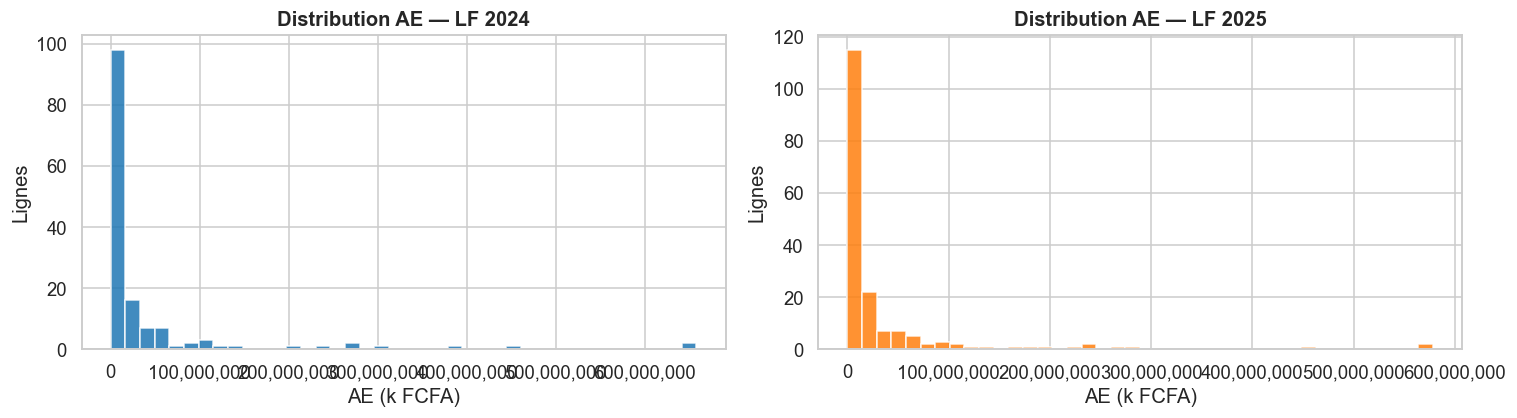

In [5]:
# Distribution AE (99e percentile)
if df_raw_2024 is not None and df_raw_2025 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, (df, annee, col) in zip(axes, [
        (df_raw_2024, 2024, COULEUR_2024),
        (df_raw_2025, 2025, COULEUR_2025)
    ]):
        df['AE'].clip(upper=df['AE'].quantile(0.99)).plot(
            kind='hist', bins=40, ax=ax, color=col, edgecolor='white', alpha=0.85
        )
        ax.set_title(f'Distribution AE — LF {annee}', fontweight='bold')
        ax.set_xlabel('AE (k FCFA)'); ax.set_ylabel('Lignes')
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout(); plt.show()


In [6]:
from audit_snd30.extraction.base import clean_ocr, clean_lib, parse_amount

# Démonstration corrections OCR
exemples = [
    'COwORDINATION MULTJLATERALE',
    'D.ECENTRALJSEE DES SERVICES',
    'AMELIORATION D.ES INFRASTRUC TURES',
    'GOUVERNENMENTALE ET INSTITUTIONELLES',
]
print(f'{"BRUT":<45} => CORRIGE')
print('-' * 80)
for t in exemples:
    print(f'{t:<45} => {clean_ocr(t)}')

print()
print('parse_amount :')
for c in [['1','234','567'], ['12','000','(XXX)'], ['5','678','90']]:
    print(f'  {c} => {parse_amount(c):,}')


BRUT                                          => CORRIGE
--------------------------------------------------------------------------------
COwORDINATION MULTJLATERALE                   => COORDINATION MULTILATÉRALE
D.ECENTRALJSEE DES SERVICES                   => DÉCENTRALISÉE DES SERVICES
AMELIORATION D.ES INFRASTRUC TURES            => AMÉLIORATION D.ES INFRASTRUC TURES
GOUVERNENMENTALE ET INSTITUTIONELLES          => GOUVERNEMENTALE ET INSTITUTIONNELLES

parse_amount :
  ['1', '234', '567'] => 1,234,567
  ['12', '000', '(XXX)'] => 12,000,000
  ['5', '678', '90'] => 567,890


---
## 2. Classification NLP — CamemBERT

```
Libelle brut
     │
     v 2a. Zero-shot (XLM-RoBERTa-XNLI)
"Cette ligne appartient au pilier X ?" -> entailment/contradiction
     │
     v 2b. Fine-tuning (camembert-base)
Pseudo-labels fiables (confiance >= 0.60) -> specialisation
     │
     v 2c. Prediction finale
PILIER_SND30 + CONFIANCE + PROB_*
```


In [7]:
from audit_snd30.nlp.classification import zero_shot, fine_tuner, predire

p24 = PROC_DIR / 'df_2024_classifie.xlsx'
p25 = PROC_DIR / 'df_2025_classifie.xlsx'

if p24.exists() and p25.exists():
    df_2024 = pd.read_excel(p24); df_2024['ANNEE'] = 2024
    df_2025 = pd.read_excel(p25); df_2025['ANNEE'] = 2025
    print(f'Classes charges : {len(df_2024)} lignes (2024), {len(df_2025)} lignes (2025)')
else:
    df_2024 = df_2025 = None
    print('Fichiers classifies absents.')

# Option A : zero-shot uniquement
# if df_raw_2024 is not None:
#     df_2024 = zero_shot(df_raw_2024)
#     df_2025 = zero_shot(df_raw_2025)

# Option B : zero-shot + fine-tuning (GPU recommande)
# df_2024_zs = zero_shot(df_raw_2024)
# scores_ft  = fine_tuner(df_2024_zs)
# df_2024    = predire(df_raw_2024)
# df_2025    = predire(df_raw_2025)


Classes charges : 145 lignes (2024), 176 lignes (2025)


In [15]:
def resumer_classification(df, annee):
    if df is None:
        print(f'[LF {annee}] non disponible'); return
    print(f'LF {annee} — Repartition par pilier')
    total = len(df)
    for p, cnt in df['PILIER_SND30'].value_counts().items():
        cible = CIBLES_SND30.get(p, 0) * 100
        obs   = cnt / total * 100
        ecart = obs - cible
        barre = '#' * int(obs / 2)
        print(f'  {p:<35} {cnt:>4} ({obs:5.1f}%) cible {cible:.0f}% ecart {ecart:+.1f}%  {barre}')
    n_v = df['A_VERIFIER'].sum() if 'A_VERIFIER' in df.columns else 'N/A'
    cm  = df['CONFIANCE'].mean()  if 'CONFIANCE'  in df.columns else None
    print(f'  A verifier : {n_v} | Confiance moy. : {cm:.4f if cm else "N/A"}')
    print()

resumer_classification(df_2024, 2024)
resumer_classification(df_2025, 2025)


LF 2024 — Repartition par pilier
  Gouvernance                           70 ( 48.3%) cible 20% ecart +28.3%  ########################
  Transformation Structurelle           39 ( 26.9%) cible 35% ecart -8.1%  #############
  Développement Régional                34 ( 23.4%) cible 15% ecart +8.4%  ###########
  Capital Humain                         2 (  1.4%) cible 30% ecart -28.6%  


ValueError: Invalid format specifier '.4f if cm else "N/A"' for object of type 'float'

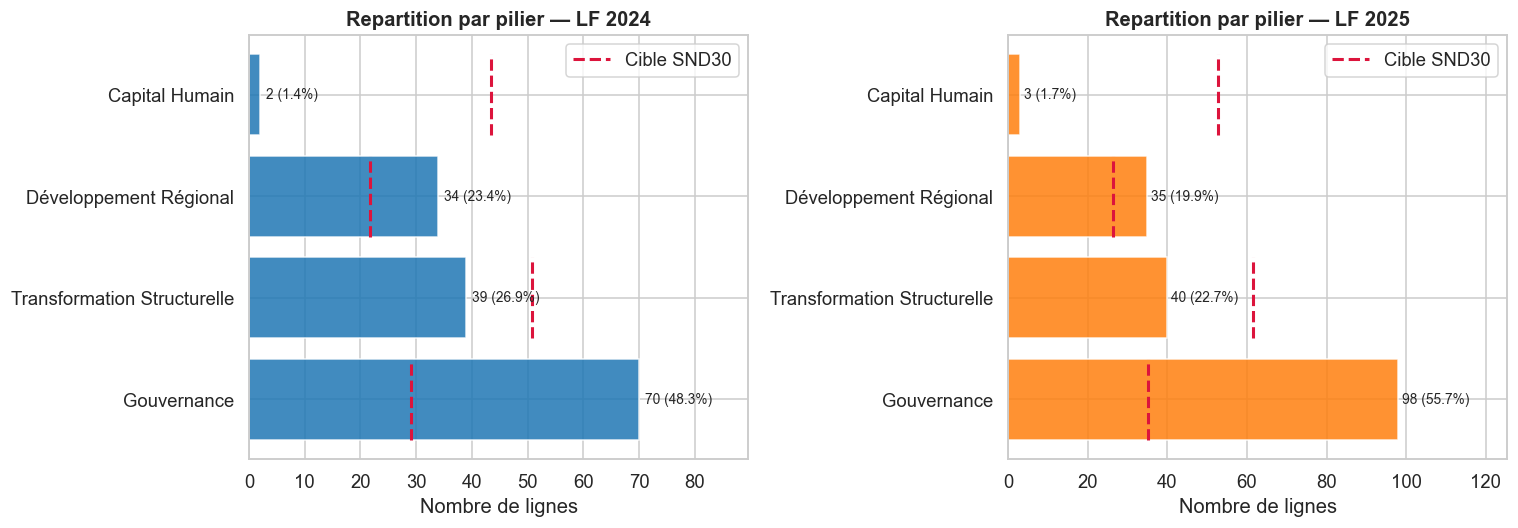

In [9]:
if df_2024 is not None and df_2025 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (df, annee, col) in zip(axes, [
        (df_2024, 2024, COULEUR_2024), (df_2025, 2025, COULEUR_2025)
    ]):
        counts = df['PILIER_SND30'].value_counts()
        bars = ax.barh(counts.index, counts.values, color=col, edgecolor='white', alpha=0.85)
        ax.set_title(f'Repartition par pilier — LF {annee}', fontweight='bold')
        ax.set_xlabel('Nombre de lignes')
        for bar, cnt in zip(bars, counts.values):
            ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                    f'{cnt} ({cnt/len(df)*100:.1f}%)', va='center', fontsize=9)
        for i, p in enumerate(counts.index):
            ax.vlines(CIBLES_SND30.get(p,0)*len(df), i-0.4, i+0.4,
                      colors='crimson', lw=2, linestyle='--',
                      label='Cible SND30' if i==0 else '')
        ax.set_xlim(0, counts.max()*1.28); ax.legend()
    plt.tight_layout(); plt.show()


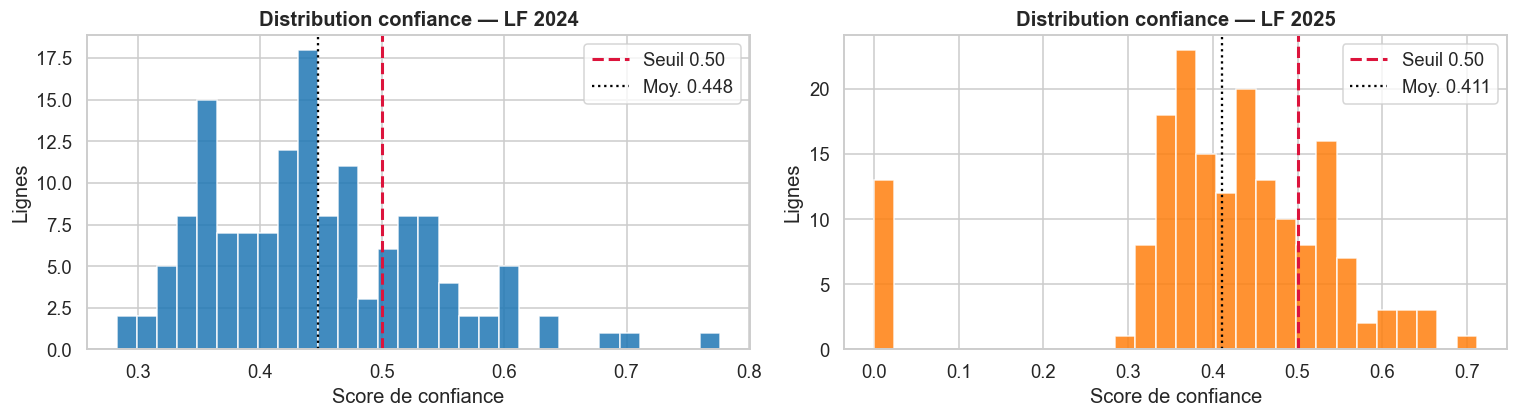

In [10]:
if df_2024 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, (df, annee, col) in zip(axes, [
        (df_2024, 2024, COULEUR_2024), (df_2025, 2025, COULEUR_2025)
    ]):
        ax.hist(df['CONFIANCE'], bins=30, color=col, edgecolor='white', alpha=0.85)
        ax.axvline(0.50, color='crimson', lw=2, linestyle='--', label='Seuil 0.50')
        ax.axvline(df['CONFIANCE'].mean(), color='black', lw=1.5, linestyle=':',
                   label=f'Moy. {df["CONFIANCE"].mean():.3f}')
        ax.set_title(f'Distribution confiance — LF {annee}', fontweight='bold')
        ax.set_xlabel('Score de confiance'); ax.set_ylabel('Lignes')
        ax.legend()
    plt.tight_layout(); plt.show()


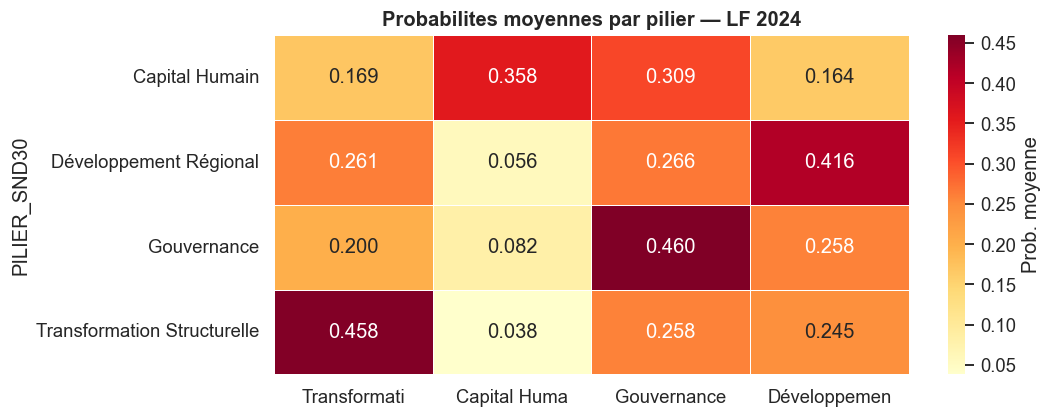

In [11]:
# Heatmap probabilites moyennes par pilier
if df_2024 is not None:
    prob_cols = [c for c in df_2024.columns if c.startswith('PROB_')]
    if prob_cols:
        prob_moy = df_2024.groupby('PILIER_SND30')[prob_cols].mean()
        prob_moy.columns = [c.replace('PROB_','').replace('_',' ').title() for c in prob_cols]
        plt.figure(figsize=(10, 4))
        sns.heatmap(prob_moy, annot=True, fmt='.3f', cmap='YlOrRd',
                    linewidths=0.5, linecolor='white', cbar_kws={'label': 'Prob. moyenne'})
        plt.title('Probabilites moyennes par pilier — LF 2024', fontweight='bold')
        plt.tight_layout(); plt.show()
    else:
        print('Colonnes PROB_* non disponibles.')


In [12]:
# Top 5 lignes AE par pilier
def top_lignes(df, pilier, annee, n=5):
    if df is None: return
    df_p = (df[df['PILIER_SND30']==pilier]
            .nlargest(n,'AE')[['LIBELLE','AE','CP','CONFIANCE']]
            .reset_index(drop=True))
    df_p.index += 1
    print(f'Top {n} — {pilier} (LF {annee})')
    display(df_p.style
        .format({'AE':'{:,.0f}','CP':'{:,.0f}','CONFIANCE':'{:.4f}'})
        .bar(subset=['AE'], color='#4e9af1')
        .bar(subset=['CONFIANCE'], color='#6dc774', vmin=0, vmax=1))

if df_2024 is not None:
    for p in PILIERS:
        top_lignes(df_2024, p, 2024)


Top 5 — Transformation Structurelle (LF 2024)


,LIBELLE,AE,CP,CONFIANCE
1,CwONSTRUCTION DES ROUTES ET AUTRES INFRASTRUCTURES,"388,719,377","348,519,377",0.4706
2,Couvrir INTERVENTIONS EN réparties INVESTISSEMENT fonctionnement,"104,624,085","104,624,085",0.4146
3,SECONDAIRES INTENSIFICATION DE LA PROFESSIONNALISATION ET OPTIMISATION DE LA FORMATION DANS LE SOUS SECTEUR DES secondaire,"100,004,000","100,004,000",0.5175
4,Améliorer AMELIORATION DE l'accès L'ACTIVITE .service JURIDICTIONNELLE Justice,"31,508,434","34,428,434",0.5257
5,PARTICIPATION DE L'ETAT DANS LES ENTREPRISES Couvrir PARAPUBLIQUES ET participation PRIVEES,"30,000,000","30,000,000",0.3997


Top 5 — Capital Humain (LF 2024)


,LIBELLE,AE,CP,CONFIANCE
1,FCFA) LIBELLE AMELIORATION DE LA GESTION DES RESSOURCES HUMAINES DE L'ETAT,"5,973,118","5,973,118",0.3766
2,PROMOTION DES DROITS DE L'HOMME,"453,100","453,100",0.3386


Top 5 — Gouvernance (LF 2024)


,LIBELLE,AE,CP,CONFIANCE
1,REMBOURSEMENT DE LA DETTE PUBLIQUE EXTERIEURE,"825,000,000","825,000,000",0.4311
2,Contribuer SUBVENTIONS ET fonctionnement . CONTRIBUTIONS organismes établissements,"445,896,000","445,896,000",0.4145
3,Couvrir DEPENSES COMMUNES DE réparties FONCTIONNEMENT fonctionnement,"304,853,000","304,853,000",0.4124
4,"REHABILITATION, MAINTENANCE ET ENTRETIEN DES ROUTES ET AUTRES","238,758,626","204,373,626",0.3779
5,OFFRE D'ENERGIE,"210,932,810","210,932,810",0.2957


Top 5 — Développement Régional (LF 2024)


,LIBELLE,AE,CP,CONFIANCE
1,LA REMBOURSEMENT DE DETTE ·PUBLIQUE engagements INTERIEURE vis-à-vis,"947,300,000","947,300,000",0.3933
2,PENSIONS,"269,668,000","269,668,000",0.3148
3,FCFA) LIBELLE LA AMELIORATION DE QUALITE DE L'EDUCATION ET DE LA VIE EN MILIEU SCOLAIRE DANS LE SOUS- SECTEUR DES SENSEIGNEMENTS,"264,833,969","264,833,969",0.3597
4,Renforcer DÉFENSE DE L'INTÉGRITÉ garantissant DU TERRITOIRE NATIONAL territoriale,"143,025,910","143,264,485",0.4754
5,RENFORCEMENT DE L'ACCES AUX ENSEIGNEMENTS SECONDAIRES,"120,585,300","120,585,300",0.4174


---
## 3. Glissement Sémantique 2024 → 2025

### Métriques

| Métrique | Formule | Interprétation |
|----------|---------|----------------|
| **Jensen-Shannon** | `JS(P||Q) = 0.5*KL(P||M) + 0.5*KL(Q||M)` | Distance entre distributions |
| **TF-IDF Cosinus** | `cos(vec_2024, vec_2025)` | Évolution du vocabulaire |
| **Δ Part AE/CP** | `part_2025(p) − part_2024(p)` | Transfert budgétaire |

| JS | Interpretation |
|-----|---------------|
| < 0.10 | Priorites stables |
| 0.10–0.25 | Reorientation partielle |
| > 0.25 | Rupture de priorites |


In [16]:
from audit_snd30.analysis.glissement import calculer_glissement
from scipy.spatial.distance import jensenshannon

if df_2024 is not None and df_2025 is not None:
    glissement = calculer_glissement(df_2024, df_2025)
    js = glissement['jensen_shannon']

    print('Glissement Semantique 2024 -> 2025')
    print(f'  Jensen-Shannon   : {js:.6f}')
    print(f'  Interpretation   : {glissement["jensen_shannon_interpretation"]}')
    print()
    print('  Delta AE par pilier :')
    for p, delta in glissement['delta_ae'].items():
        sens = 'UP' if delta > 0 else 'DOWN' if delta < 0 else '='
        print(f'    {p:<35} : {delta:+.2f}% [{sens}]')
    print()
    print('  TF-IDF Cosinus :')
    for p, score in glissement['cosine_tfidf'].items():
        print(f'    {p:<35} : {score:.4f}' if score is not None else f'    {p:<35} : N/A')
else:
    glissement = None
    print('Donnees non disponibles.')


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 220.31it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Glissement Semantique 2024 -> 2025
  Jensen-Shannon   : 0.054900
  Interpretation   : Faible glissement (priorités stables)

  Delta AE par pilier :
    Transformation Structurelle         : +38.01% [UP]
    Capital Humain                      : +0.02% [UP]
    Gouvernance                         : -16.06% [DOWN]
    Développement Régional              : -21.96% [DOWN]

  TF-IDF Cosinus :
    Transformation Structurelle         : 0.8374
    Capital Humain                      : 0.6456
    Gouvernance                         : 0.9499
    Développement Régional              : 0.7376


In [17]:
# Verification manuelle Jensen-Shannon
if df_2024 is not None and glissement:
    P = np.array([df_2024['PILIER_SND30'].value_counts(normalize=True).get(p,0) for p in PILIERS])
    Q = np.array([df_2025['PILIER_SND30'].value_counts(normalize=True).get(p,0) for p in PILIERS])
    P = np.clip(P,1e-10,None); P/=P.sum()
    Q = np.clip(Q,1e-10,None); Q/=Q.sum()
    M = (P+Q)/2
    kl_pm = float(np.sum(P*np.log(P/M)))
    kl_qm = float(np.sum(Q*np.log(Q/M)))
    js_c  = 0.5*kl_pm + 0.5*kl_qm

    print('Verification Jensen-Shannon')
    for p, pi, qi in zip(PILIERS, P, Q):
        print(f'  {p:<35} P={pi:.4f}  Q={qi:.4f}')
    print(f'\n  KL(P||M) = {kl_pm:.6f}')
    print(f'  KL(Q||M) = {kl_qm:.6f}')
    print(f'  JS calcule  = {js_c:.6f}')
    print(f'  JS scipy    = {jensenshannon(P,Q):.6f}  (verification OK)')


Verification Jensen-Shannon
  Transformation Structurelle         P=0.2690  Q=0.2273
  Capital Humain                      P=0.0138  Q=0.0170
  Gouvernance                         P=0.4828  Q=0.5568
  Développement Régional              P=0.2345  Q=0.1989

  KL(P||M) = 0.003005
  KL(Q||M) = 0.003026
  JS calcule  = 0.003016
  JS scipy    = 0.054914  (verification OK)


In [19]:
# Jauge Jensen-Shannon (Plotly)
if df_2024 is not None and glissement:
    js  = glissement['jensen_shannon']
    cj  = '#27AE60' if js < 0.10 else '#F39C12' if js < 0.25 else '#E74C3C'
    fig = go.Figure(go.Indicator(
        mode='gauge+number+delta',
        value=js,
        number={'valueformat':'.4f'},
        title={'text':'Glissement Semantique JS<br><sub>LF 2024 -> LF 2025</sub>'},
        delta={'reference':0.10,'decreasing':{'color':'green'},'increasing':{'color':'red'}},
        gauge={
            'axis':{'range':[0,1]},
            'bar':{'color':cj,'thickness':0.3},
            'steps':[
                {'range':[0.00,0.10],'color':'#D5F5E3'},
                {'range':[0.10,0.25],'color':'#FCF3CF'},
                {'range':[0.25,1.00],'color':'#FADBD8'},
            ],
            'threshold':{'line':{'color':'navy','width':3},'thickness':0.75,'value':0.25}
        }
    ))
    fig.update_layout(height=380, paper_bgcolor='white', font={'size':14})
    fig.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [20]:
# Comparatif AE 2024 vs 2025 vs Cibles
if df_2024 is not None and glissement:
    parts_ae = glissement['parts_ae']
    fig = go.Figure()
    for annee, col in [(2024,COULEUR_2024),(2025,COULEUR_2025)]:
        fig.add_trace(go.Bar(
            name=f'LF {annee}', x=PILIERS,
            y=[parts_ae[annee][p] for p in PILIERS],
            marker_color=col, opacity=0.85,
            text=[f'{parts_ae[annee][p]:.1f}%' for p in PILIERS], textposition='outside'
        ))
    fig.add_trace(go.Scatter(
        name='Cible SND30', x=PILIERS,
        y=[CIBLES_SND30[p]*100 for p in PILIERS],
        mode='markers+lines',
        marker=dict(size=14,symbol='diamond',color='black'),
        line=dict(color='black',dash='dash',width=2)
    ))
    fig.update_layout(
        title='Part des AE par pilier — LF 2024 vs LF 2025 vs Cibles SND30',
        barmode='group', yaxis_title='Part AE (%)',
        xaxis_tickangle=-15, height=480,
        legend=dict(orientation='h',y=-0.3),
        plot_bgcolor='white', paper_bgcolor='white'
    )
    fig.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

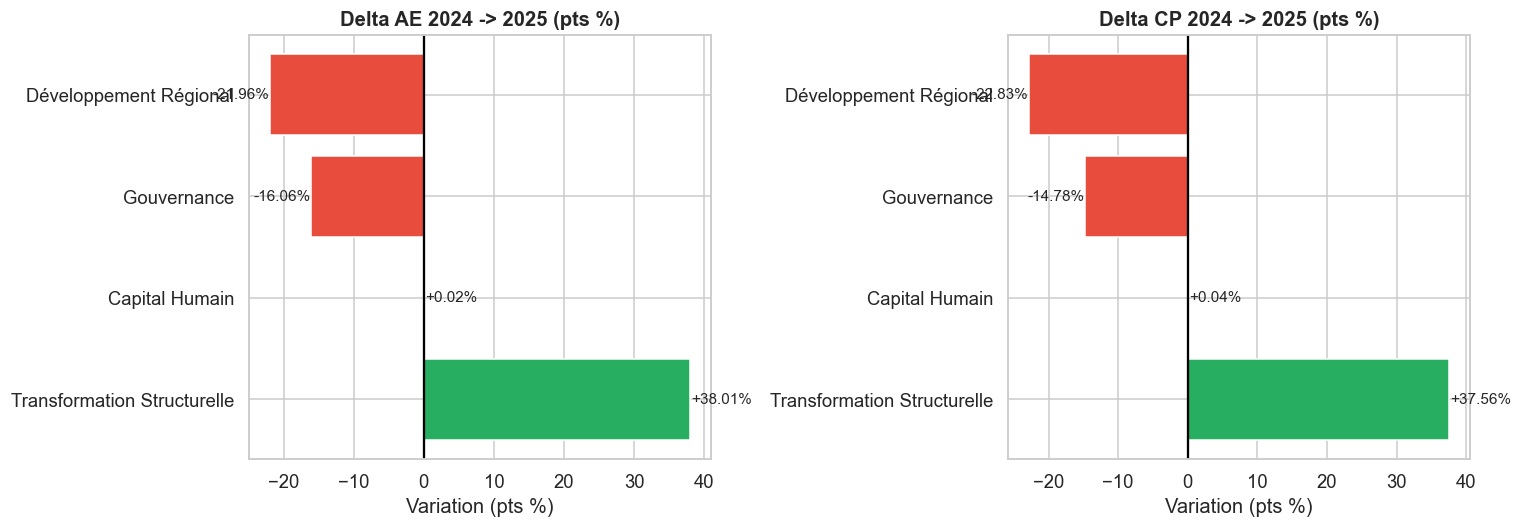

In [21]:
# Delta AE et CP
if df_2024 is not None and glissement:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for ax, delta, titre in [
        (ax1, glissement['delta_ae'], 'Delta AE 2024 -> 2025 (pts %)'),
        (ax2, glissement['delta_cp'], 'Delta CP 2024 -> 2025 (pts %)')
    ]:
        colors = ['#27AE60' if v>=0 else '#E74C3C' for v in delta.values()]
        bars = ax.barh(list(delta.keys()), list(delta.values()),
                       color=colors, edgecolor='white')
        ax.axvline(0, color='black', lw=1.5)
        ax.set_title(titre, fontweight='bold')
        ax.set_xlabel('Variation (pts %)')
        for bar, val in zip(bars, delta.values()):
            ax.text(val+(0.1 if val>=0 else -0.1), bar.get_y()+bar.get_height()/2,
                    f'{val:+.2f}%', va='center',
                    ha='left' if val>=0 else 'right', fontsize=10)
    plt.tight_layout(); plt.show()


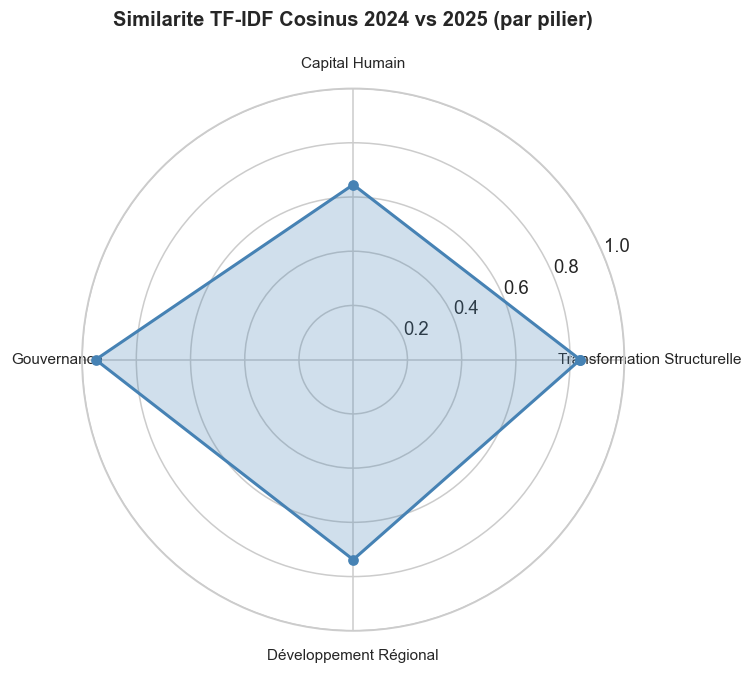

In [22]:
# Radar TF-IDF Cosinus
if df_2024 is not None and glissement:
    cosine = glissement['cosine_tfidf']
    vals   = [cosine.get(p) or 0 for p in PILIERS]
    angles = np.linspace(0, 2*np.pi, len(PILIERS), endpoint=False).tolist()
    angles += angles[:1]
    vals_r  = vals + vals[:1]

    fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
    ax.fill(angles, vals_r, color='steelblue', alpha=0.25)
    ax.plot(angles, vals_r, 'o-', color='steelblue', lw=2)
    ax.set_thetagrids(np.degrees(angles[:-1]), PILIERS, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title('Similarite TF-IDF Cosinus 2024 vs 2025 (par pilier)',
                 fontweight='bold', pad=20)
    plt.tight_layout(); plt.show()


---
## 4. Alignement Statistique — Test du Chi²

$$\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}, \quad ddl = k-1 = 3$$

- **H₀** : distribution observée = cibles SND30 → **aligné** (p > 0.05)
- **H₁** : écart significatif → **désaligné** (p < 0.05)


In [23]:
from audit_snd30.analysis.alignement import test_alignement
from scipy.stats import chi2

if df_2024 is not None and df_2025 is not None:
    alignement = test_alignement(df_2024, df_2025)
    ddl   = len(PILIERS) - 1
    seuil = chi2.ppf(0.95, df=ddl)

    print('Test alignement Chi^2 vs Cibles SND30')
    print(f'  Valeur critique chi^2(0.95, ddl={ddl}) = {seuil:.4f}')
    print()
    for _, row in alignement.iterrows():
        icone = 'ALIGNE' if row['P_VALUE'] > 0.05 else 'DESALIGNE'
        print(f'  LF {int(row["ANNEE"])} : chi2={row["CHI2"]:.4f}  p={row["P_VALUE"]:.4f}  => {icone}')
    print()
    for _, row in alignement.iterrows():
        print(f'  {row["INTERPRETATION"]}')
else:
    alignement = None
    print('Donnees non disponibles.')


Test alignement Chi^2 vs Cibles SND30
  Valeur critique chi^2(0.95, ddl=3) = 7.8147

  LF 2024 : chi2=107.1773  p=0.0000  => DESALIGNE
  LF 2025 : chi2=169.3869  p=0.0000  => DESALIGNE

  LF 2024 : désalignement statistiquement prouvé (p=0.000 < 0.05)
  LF 2025 : désalignement statistiquement prouvé (p=0.000 < 0.05)


In [24]:
# Calcul detaille Chi^2 — LF 2024
if df_2024 is not None:
    n = len(df_2024)
    print(f'Calcul detaille Chi^2 — LF 2024  (N={n})')
    print(f'{"Pilier":<35} {"O":>6} {"E":>8} {"(O-E)^2/E":>10}')
    print('-' * 65)
    chi2_tot = 0.0
    for p in PILIERS:
        O = len(df_2024[df_2024['PILIER_SND30'] == p])
        E = CIBLES_SND30[p] * n
        t = (O - E)**2 / E
        chi2_tot += t
        print(f'{p:<35} {O:>6} {E:>8.1f} {t:>10.4f}')
    ddl   = len(PILIERS) - 1
    p_val = 1 - chi2.cdf(chi2_tot, df=ddl)
    print('-' * 65)
    print(f'chi2 = {chi2_tot:.4f}  |  ddl = {ddl}  |  p = {p_val:.4f}')
    print('Decision :', 'ALIGNE (H0 conservee)' if p_val > 0.05 else 'DESALIGNE (H0 rejetee)')


Calcul detaille Chi^2 — LF 2024  (N=145)
Pilier                                   O        E  (O-E)^2/E
-----------------------------------------------------------------
Transformation Structurelle             39     50.8     2.7204
Capital Humain                           2     43.5    39.5920
Gouvernance                             70     29.0    57.9655
Développement Régional                  34     21.8     6.8994
-----------------------------------------------------------------
chi2 = 107.1773  |  ddl = 3  |  p = 0.0000
Decision : DESALIGNE (H0 rejetee)


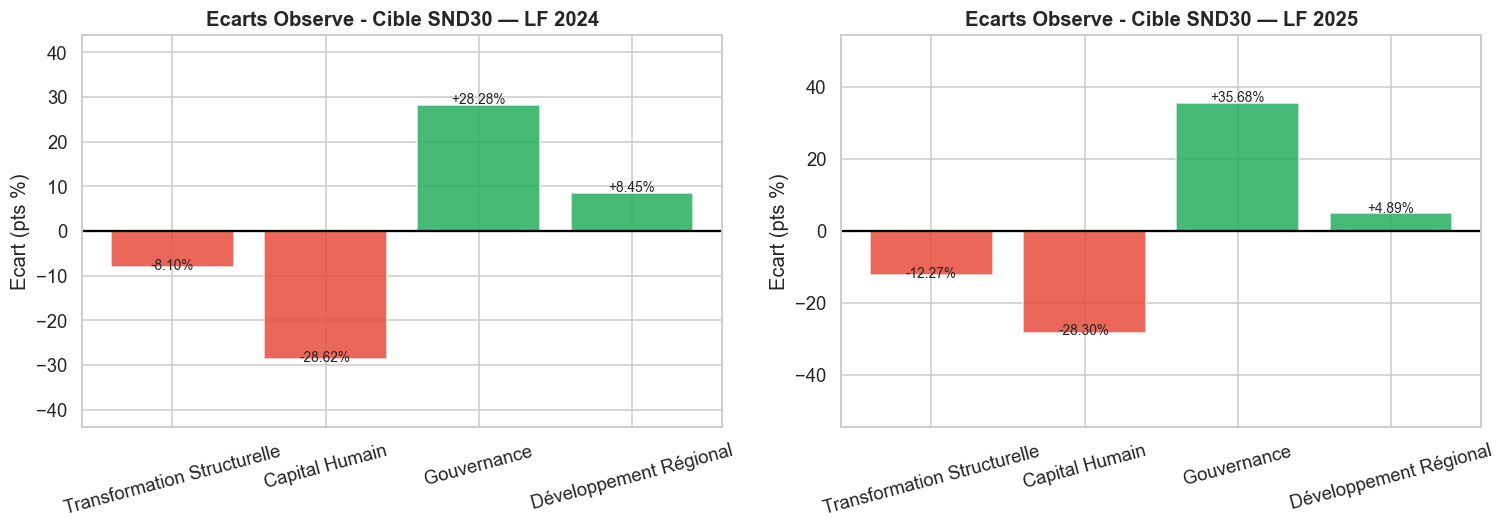

In [25]:
# Ecarts observé - attendu
if df_2024 is not None and alignement is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (_, row) in zip(axes, alignement.iterrows()):
        ecarts = row['ECARTS_PAR_PILIER']
        colors = ['#27AE60' if v>=0 else '#E74C3C' for v in ecarts.values()]
        bars = ax.bar(list(ecarts.keys()), list(ecarts.values()),
                      color=colors, edgecolor='white', alpha=0.85)
        ax.axhline(0, color='black', lw=1.5)
        ax.set_title(f'Ecarts Observe - Cible SND30 — LF {int(row["ANNEE"])}',
                     fontweight='bold')
        ax.set_ylabel('Ecart (pts %)')
        ax.tick_params(axis='x', rotation=15)
        for bar, val in zip(bars, ecarts.values()):
            ax.text(bar.get_x()+bar.get_width()/2, val+(0.3 if val>=0 else -0.6),
                    f'{val:+.2f}%', ha='center', fontsize=9)
        hi = max(abs(v) for v in ecarts.values()) * 1.5 + 1
        ax.set_ylim(-hi, hi)
    plt.tight_layout(); plt.show()


---
## 5. Tableau de Bord Synthétique (Plotly)

In [26]:
if df_2024 is not None and glissement and alignement is not None:
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=['Repartition AE 2024','Repartition AE 2025',
                        'AE par pilier vs Cibles','Glissement Delta AE'],
        specs=[[{'type':'pie'},{'type':'pie'}],[{'type':'bar'},{'type':'bar'}]]
    )

    for col_idx, (df, annee) in enumerate([(df_2024,2024),(df_2025,2025)], 1):
        ae_p = {p: df[df['PILIER_SND30']==p]['AE'].sum() for p in PILIERS}
        fig.add_trace(go.Pie(
            labels=list(ae_p.keys()), values=list(ae_p.values()),
            marker_colors=[COULEURS_PILIERS[p] for p in PILIERS],
            textinfo='percent+label', showlegend=False, hole=0.3
        ), row=1, col=col_idx)

    parts_ae = glissement['parts_ae']
    for annee, col in [(2024,COULEUR_2024),(2025,COULEUR_2025)]:
        fig.add_trace(go.Bar(
            name=f'LF {annee}', x=PILIERS,
            y=[parts_ae[annee][p] for p in PILIERS],
            marker_color=col, opacity=0.85
        ), row=2, col=1)
    fig.add_trace(go.Scatter(
        name='Cible SND30', x=PILIERS,
        y=[CIBLES_SND30[p]*100 for p in PILIERS],
        mode='markers+lines',
        marker=dict(size=12,symbol='diamond',color='black'),
        line=dict(color='black',dash='dash')
    ), row=2, col=1)

    delta_ae = glissement['delta_ae']
    fig.add_trace(go.Bar(
        x=PILIERS, y=[delta_ae[p] for p in PILIERS],
        marker_color=['#27AE60' if delta_ae[p]>=0 else '#E74C3C' for p in PILIERS],
        text=[f'{delta_ae[p]:+.2f}%' for p in PILIERS], textposition='outside',
        showlegend=False
    ), row=2, col=2)

    fig.update_layout(
        height=700, barmode='group',
        title_text='Tableau de Bord SND30 — Audit Budgetaire Cameroun 2024-2025',
        plot_bgcolor='white', paper_bgcolor='white'
    )
    fig.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [28]:
# KPI HTML
if df_2024 is not None and glissement and alignement is not None:
    js = glissement.get('jensen_shannon', 0)
    r24 = alignement[alignement['ANNEE']==2024].iloc[0]
    r25 = alignement[alignement['ANNEE']==2025].iloc[0]

    kpis = [
        ('Lignes LF 2024',          f'{len(df_2024):,}'),
        ('Lignes LF 2025',          f'{len(df_2025):,}'),
        ('Variation de lignes',     f'{len(df_2025)-len(df_2024):+,}'),
        ('Total AE 2024 (k FCFA)',   f'{df_2024["AE"].sum():,.0f}'),
        ('Total AE 2025 (k FCFA)',   f'{df_2025["AE"].sum():,.0f}'),
        ('Jensen-Shannon',          f'{js:.6f}'),
        ('Interpretation JS',       glissement['jensen_shannon_interpretation']),
        ('Alignement LF 2024',      f'{r24["ALIGNEMENT"]}  (chi2={r24["CHI2"]}, p={r24["P_VALUE"]})'),
        ('Alignement LF 2025',      f'{r25["ALIGNEMENT"]}  (chi2={r25["CHI2"]}, p={r25["P_VALUE"]})'),
    ]
    html = '<table style="border-collapse:collapse;font-family:monospace;font-size:13px;width:100%">'
    html += '<tr style="background:#1F4E79;color:white"><th style="padding:8px;text-align:left">Indicateur</th><th style="padding:8px;text-align:left">Valeur</th></tr>'
    for i,(k,v) in enumerate(kpis):
        bg = '#f0f4fa' if i%2==0 else 'white'
        html += f'<tr style="background:{bg}"><td style="padding:7px 10px">{k}</td><td style="padding:7px 10px;font-weight:bold">{v}</td></tr>'
    html += '</table>'
    display(HTML(html))


Indicateur,Valeur
Lignes LF 2024,145
Lignes LF 2025,176
Variation de lignes,+31
Total AE 2024 (k FCFA),"6,286,742,197"
Total AE 2025 (k FCFA),"7,122,302,111"
Jensen-Shannon,0.054900
Interpretation JS,Faible glissement (priorités stables)
Alignement LF 2024,"✗ Désaligné (chi2=107.1773, p=0.0)"
Alignement LF 2025,"✗ Désaligné (chi2=169.3869, p=0.0)"


---
## 6. Exploration des Embeddings (SentenceTransformer + UMAP)

In [29]:
from audit_snd30.analysis.embeddings_explorer import construire_embeddings_df

if df_2024 is not None and df_2025 is not None:
    df_all = pd.concat([df_2024, df_2025], ignore_index=True)
    print(f'Calcul UMAP 2D sur {len(df_all)} libelles (max 300 par pilier)...')
    df_emb = construire_embeddings_df(
        df_all, text_col='LIBELLE', label_col='PILIER_SND30',
        year_col='ANNEE', max_par_pilier=300
    )
    print(f'OK : {len(df_emb)} points projetes')
    display(df_emb.head())
else:
    df_emb = None
    print('Donnees non disponibles.')


Calcul UMAP 2D sur 321 libelles (max 300 par pilier)...
OK : 321 points projetes


,x,y,PILIER_SND30,LIBELLE,ANNEE
0,7.071688,-2.259688,Capital Humain,PROMOTION DES DROITS DE L'HOMME,2024
1,7.092695,-2.255136,Capital Humain,PROMOTION DES DROITS DE L'HOMME,2025
2,1.904438,-0.465787,Capital Humain,PROMOTION DE L'EMPLOI DÉCENT ET DE L'INSERTION...,2025
3,3.572512,0.300860,Capital Humain,FCFA) LIBELLE AMELIORATION DE LA GESTION DES R...,2024
4,3.716779,0.349553,Capital Humain,AMÉLIORATION DE LA GESTION DES RESSOURCES HUMA...,2025


In [30]:
if df_emb is not None:
    fig = px.scatter(
        df_emb, x='x', y='y', color='PILIER_SND30',
        hover_data=['ANNEE','LIBELLE'],
        color_discrete_map=COULEURS_PILIERS,
        title='Espace semantique UMAP — colore par pilier SND30',
        height=560, opacity=0.75
    )
    fig.update_traces(marker=dict(size=5))
    fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
    fig.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
if df_emb is not None:
    fig = px.scatter(
        df_emb, x='x', y='y', color='ANNEE',
        color_discrete_sequence=[COULEUR_2024, COULEUR_2025],
        hover_data=['PILIER_SND30','LIBELLE'],
        title='Espace semantique UMAP — glissement 2024 -> 2025',
        height=560, opacity=0.65
    )
    fig.update_traces(marker=dict(size=5))
    fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
    fig.show()


---
## 7. Tests Unitaires (reproductibles sans PDF)

In [ ]:
from scipy.stats import chi2 as chi2_dist

# Donnees synthetiques (miroir de tests/test_analysis.py)
rng24 = np.random.default_rng(42)
df_s24 = pd.DataFrame({
    'LIBELLE':      [f'Programme {i}' for i in range(120)],
    'AE':           rng24.integers(500_000, 50_000_000, 120),
    'CP':           rng24.integers(500_000, 50_000_000, 120),
    'PILIER_SND30': rng24.choice(PILIERS, 120, p=[.35,.30,.20,.15]),
    'CONFIANCE':    rng24.uniform(.5,.99,120).round(4),
    'A_VERIFIER':   [False]*120, 'ANNEE': [2024]*120,
})
rng25 = np.random.default_rng(99)
df_s25 = df_s24.iloc[:115].copy()
df_s25['PILIER_SND30'] = rng25.choice(PILIERS, 115, p=[.40,.28,.18,.14])
df_s25['ANNEE']  = 2025
df_s25['AE']     = rng25.integers(500_000, 55_000_000, 115)
df_s25['CP']     = rng25.integers(500_000, 55_000_000, 115)

print(f'Synthetiques : {len(df_s24)} lignes (2024), {len(df_s25)} lignes (2025)')


In [ ]:
passed = []

# T1 : cles de glissement
g = calculer_glissement(df_s24, df_s25)
assert {'jensen_shannon','cosine_tfidf','delta_ae','parts_ae'}.issubset(g.keys())
passed.append('T1 Cles glissement')

# T2 : JS dans [0,1]
js_v = g['jensen_shannon']
assert 0.0 <= js_v <= 1.0
passed.append('T2 JS dans [0,1]')

# T3 : JS=0 si distributions identiques
assert abs(calculer_glissement(df_s24, df_s24)['jensen_shannon']) < 1e-6
passed.append('T3 JS=0 (identiques)')

# T4 : distributions somment a 1
for yr in [2024,2025]:
    assert abs(sum(g['distributions'][yr].values()) - 1.0) < 1e-4
passed.append('T4 Somme distributions = 1')

# T5 : alignement — 2 lignes, bornes ok
a = test_alignement(df_s24, df_s25)
assert len(a)==2 and (a['CHI2']>=0).all() and ((a['P_VALUE']>=0)&(a['P_VALUE']<=1)).all()
passed.append('T5 Chi2 (dimensions + bornes)')

# T6 : distribution parfaite -> alignee
n_t, perf = 1000, []
for p, prop in CIBLES_SND30.items():
    perf.extend([p]*int(prop*n_t))
df_perf = pd.DataFrame({
    'LIBELLE':[f'l{i}' for i in range(len(perf))],
    'AE':[1_000_000]*len(perf),'CP':[1_000_000]*len(perf),
    'PILIER_SND30':perf,'CONFIANCE':[.9]*len(perf),
    'A_VERIFIER':[False]*len(perf),'ANNEE':[2024]*len(perf),
})
assert (test_alignement(df_perf, df_perf)['P_VALUE'] > 0.05).all()
passed.append('T6 Distribution parfaite alignee')

# T7 : OCR utilities
from audit_snd30.extraction.base import parse_amount, clean_lib, clean_ocr
assert parse_amount(['1','234','567']) == 1234567
assert parse_amount([]) is None
assert '  ' not in clean_lib('PROG   DE   DEV')
assert 'COORDINATION' in clean_ocr('COwORDINATION DES ACTIONS')
assert 'MULTILATERALE' in clean_ocr('MULTJLATERALE COOPERATION')
passed.append('T7 OCR utilities')

print('=' * 52)
print('  RESULTATS DES TESTS')
print('=' * 52)
for t in passed:
    print(f'  OK  {t}')
print('=' * 52)
print(f'  {len(passed)}/{len(passed)} tests passes')
print(f'  JS synthetique 2024->2025 = {js_v:.6f}')


---
## 8. Rapport Technique Final

In [ ]:
params = {
    'Modele zero-shot':           ZEROSHOT_MODEL,
    'Modele fine-tuning':         FINETUNE_MODEL,
    'Modele embedding':           EMBEDDING_MODEL,
    'Epochs max':                 TRAIN_EPOCHS,
    'Batch size':                 BATCH_SIZE,
    'Learning rate':              LEARNING_RATE,
    'Weight decay':               WEIGHT_DECAY,
    'Warmup ratio':               WARMUP_RATIO,
    'Early stopping (patience)':  EARLY_STOP_PAT,
    'Seuil zero-shot':            SEUIL_ZEROSHOT,
    'Seuil prediction':           SEUIL_PRED,
    'Seuil fine-tuning':          MIN_CONFIANCE_FT,
}
df_params = pd.DataFrame.from_dict(params, orient='index', columns=['Valeur'])
display(df_params.style
    .set_table_styles([{
        'selector':'th',
        'props':[('background','#1F4E79'),('color','white'),('font-weight','bold')]
    }])
    .set_caption('Hyperparametres CamemBERT SND30')
)


In [ ]:
if df_2024 is not None and glissement and alignement is not None:
    js  = glissement.get('jensen_shannon', 0)
    r24 = alignement[alignement['ANNEE']==2024].iloc[0]
    r25 = alignement[alignement['ANNEE']==2025].iloc[0]

    print('=' * 72)
    print('  RAPPORT FINAL — AUDIT SEMANTIQUE SND30 2024-2025')
    print('  ISE3-DS | ISSEA Yaounde | 2025-2026  (Chouta et Ambassa)')
    print('=' * 72)

    print('\n  DONNEES')
    print(f'    LF 2024 : {len(df_2024):,} lignes | AE = {df_2024["AE"].sum():,.0f} k FCFA')
    print(f'    LF 2025 : {len(df_2025):,} lignes | AE = {df_2025["AE"].sum():,.0f} k FCFA')

    print('\n  QUALITE CLASSIFICATION')
    for annee, df in [(2024, df_2024),(2025, df_2025)]:
        n_v = df['A_VERIFIER'].sum() if 'A_VERIFIER' in df.columns else 'N/A'
        cm  = df['CONFIANCE'].mean()  if 'CONFIANCE'  in df.columns else None
        print(f'    LF {annee} : confiance moy = {cm:.4f if cm else "N/A"} | a verifier = {n_v}')

    print('\n  GLISSEMENT SEMANTIQUE')
    niveau = 'stable' if js < 0.10 else 'modere' if js < 0.25 else 'fort'
    print(f'    Jensen-Shannon = {js:.6f}  [{niveau}]')
    print(f'    {glissement["jensen_shannon_interpretation"]}')
    max_p = max(glissement['delta_ae'], key=lambda k: abs(glissement['delta_ae'][k]))
    print(f'    Plus fort Delta AE : {max_p} ({glissement["delta_ae"][max_p]:+.2f} pts)')

    print('\n  ALIGNEMENT SND30 (Chi^2)')
    for _, row in alignement.iterrows():
        icone = 'OK' if row['P_VALUE'] > 0.05 else 'ECART'
        print(f'    [{icone}] LF {int(row["ANNEE"])} : chi2={row["CHI2"]:.4f}  p={row["P_VALUE"]:.4f}  {row["ALIGNEMENT"]}')

    print('\n' + '=' * 72)


---
## 9. Lancement Dashboard Streamlit

```bash
# Depuis le terminal
poetry run streamlit run audit_snd30/dashboard/app.py
# Ouvrir http://localhost:8501
```

---
## Références

| Ressource | Référence |
|-----------|----------|
| CamemBERT | Martin et al. (2020), *CamemBERT: a Tasty French Language Model* |
| XLM-RoBERTa | Conneau et al. (2020), *Unsupervised Cross-lingual Representation Learning* |
| Jensen-Shannon | Lin (1991), *Divergence Measures Based on the Shannon Entropy* |
| UMAP | McInnes et al. (2018), *UMAP: Uniform Manifold Approximation and Projection* |
| SND30 | MINEPAT (2020), *Strategie Nationale de Developpement 2020-2030* |
| MINFI | Budget de l'Etat — Lois de Finances 2023-2024 et 2024-2025 |

---
*ISE3-DS · ISSEA Yaounde · 2025-2026 — Chouta et Ambassa*
